<a href="https://colab.research.google.com/github/HiyoriVn/CSE_Machine-Learning/blob/main/Gradient_Descent_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import base64

plt.rcParams['animation.embed_limit'] = 50
np.random.seed(2)

Solution found by formula: w =  [[4.0071715  2.98225924]]


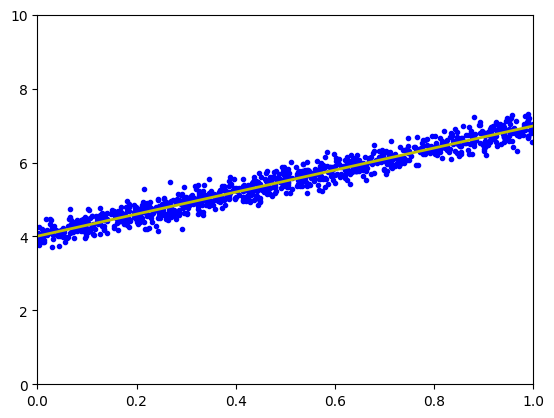

In [ ]:
X = np.random.rand(1000, 1)
y = 4 + 3 * X + .2*np.random.randn(1000, 1) # noise added

# Building Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w_lr = np.dot(np.linalg.pinv(A), b)
print('Solution found by formula: w = ',w_lr.T)

# Display result
w = w_lr
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(0, 1, 2, endpoint=True)
y0 = w_0 + w_1*x0

# Draw the fitting line
plt.plot(X.T, y.T, 'b.')     # data
plt.plot(x0, y0, 'y', linewidth = 2)   # the fitting line
plt.axis([0, 1, 0, 10])
plt.show()

In [ ]:
def grad(w):
    N = Xbar.shape[0]
    return 1/N * Xbar.T.dot(Xbar.dot(w) - y)

def cost(w):
    N = Xbar.shape[0]
    return .5/N*np.linalg.norm(y - Xbar.dot(w), 2)**2;

In [ ]:
def numerical_grad(w, cost):
    eps = 1e-4
    g = np.zeros_like(w)
    for i in range(len(w)):
        w_p = w.copy()
        w_n = w.copy()
        w_p[i] += eps
        w_n[i] -= eps
        g[i] = (cost(w_p) - cost(w_n))/(2*eps)
    return g

def check_grad(w, cost, grad):
    w = np.random.rand(w.shape[0], w.shape[1])
    grad1 = grad(w)
    grad2 = numerical_grad(w, cost)
    return True if np.linalg.norm(grad1 - grad2) < 1e-6 else False

print( 'Checking gradient...', check_grad(np.random.rand(2, 1), cost, grad))

Checking gradient... True


In [ ]:
def myGD(w_init, grad, eta):
    w = [w_init]
    for it in range(100):
        w_new = w[-1] - eta*grad(w[-1])
        if np.linalg.norm(grad(w_new))/len(w_new) < 1e-3:
            break
        w.append(w_new)
    return (w, it)

eta = 1
w_init = np.array([[2], [1]])
(w_history, it) = myGD(w_init, grad, eta)
print('Solution found by GD: w = ', w_history[-1].T, ',\nafter %d iterations.' % (it+1))

Solution found by GD: w =  [[4.02199496 2.95380036]] ,
after 50 iterations.


In [ ]:
w0_range = np.linspace(1.5, 5.5, 100)
w1_range = np.linspace(0.5, 4.5, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)

Z = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w_ij = np.array([[W0[i, j]], [W1[i, j]]])
        Z[i, j] = cost(w_ij)

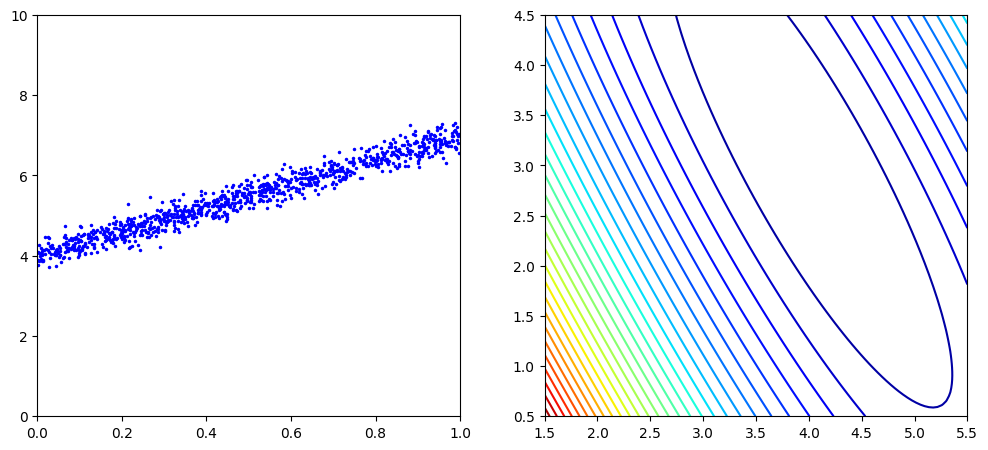

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

ax1.plot(X, y, 'b.', markersize=3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 10)
x0_line = np.linspace(0, 1, 2)

fit_line, = ax1.plot([], [], 'r', linewidth=2)

ax2.contour(W0, W1, Z, levels=30, cmap='jet')
ax2.set_xlim(w0_range[0], w0_range[-1])
ax2.set_ylim(w1_range[0], w1_range[-1])

path_line, = ax2.plot([], [], 'r-', linewidth=1)
path_points, = ax2.plot([], [], 'ro', markersize=4)
start_point, = ax2.plot([], [], 'ro', markersize=6)
current_point, = ax2.plot([], [], 'go', markersize=6)

# Text đặt bên dưới ax1, canh giữa bằng cả 2 subplot (dùng toạ độ figure qua ax1)
info_text = ax1.text(1.1, -0.12, '', transform=ax1.transAxes,
                      ha='center', va='top', fontsize=11)

fig.subplots_adjust(bottom=0.15)

def init():
    fit_line.set_data([], [])
    path_line.set_data([], [])
    path_points.set_data([], [])
    start_point.set_data([], [])
    current_point.set_data([], [])
    info_text.set_text('')
    return fit_line, path_line, path_points, start_point, current_point, info_text

def update(frame):
    w = w_history[frame]
    w0_val, w1_val = w[0][0], w[1][0]

    y0_line = w0_val + w1_val*x0_line
    fit_line.set_data(x0_line, y0_line)

    ws_so_far = w_history[:frame+1]
    w0_list = [ww[0][0] for ww in ws_so_far]
    w1_list = [ww[1][0] for ww in ws_so_far]

    path_line.set_data(w0_list, w1_list)
    path_points.set_data(w0_list, w1_list)
    start_point.set_data([w0_list[0]], [w1_list[0]])
    current_point.set_data([w0_val], [w1_val])

    grad_norm = np.linalg.norm(grad(w))
    info_text.set_text(r'$\eta$ = %d; iter = %d/%d; $||grad||_2$ = %.3f' %
                        (eta, frame, it, grad_norm))

    return fit_line, path_line, path_points, start_point, current_point, info_text


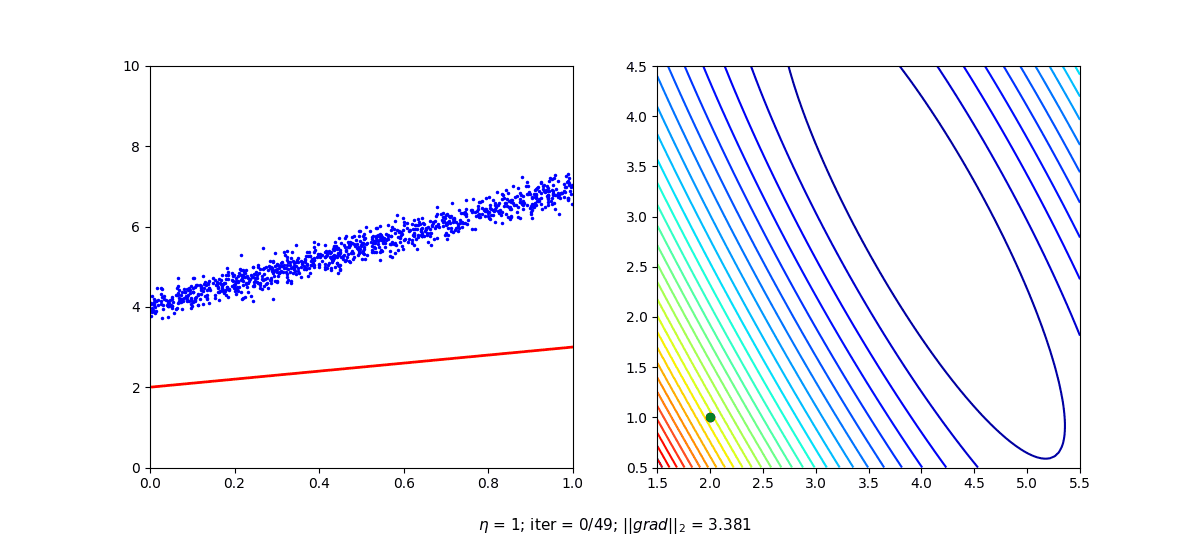

In [ ]:
anim = animation.FuncAnimation(
    fig, update, frames=len(w_history),
    init_func=init, interval=300, blit=True, repeat=True
)
plt.close(fig)

anim.save('gd_linreg.gif', writer='pillow', fps=4)

with open('gd_linreg.gif', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode('ascii')

HTML(f'<img src="data:image/gif;base64,{b64}" />')